### Импорт модулей проекта
Настройка путей для корректного импорта модулей из родительской директории.

In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

### Импорт необходимых библиотек

**Структура импортов:**
- Базовые библиотеки для анализа данных (pandas, numpy)
- Визуализация (matplotlib, seaborn)
- Инструменты для предобработки данных из sklearn
- Алгоритмы машинного обучения
- Gradient Boosting библиотеки (CatBoost, XGBoost)

In [208]:
from utils import *


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("../data/spam/raw_data.csv")
df.drop(labels=["Unnamed: 0"],axis=1,inplace=True)

In [4]:
df.head()

,message,label
0,Привет чтото подобное делал если через usb исп...,0
1,"Я уже сам отключил, через старлайн мастер",0
2,Страны ес согласовали санкции против белорусск...,0
3,"Кипячу, не кипячусь я добрая пока",0
4,"Avalonia for visual studio 2019,2017 не удаетс...",0


In [5]:
df.shape

(4511513, 2)

In [6]:
df.duplicated().sum()

np.int64(0)

## Балансировка датасета

Визуализируем баланс классов в датасете с помощью круговой диаграммы (pie chart).

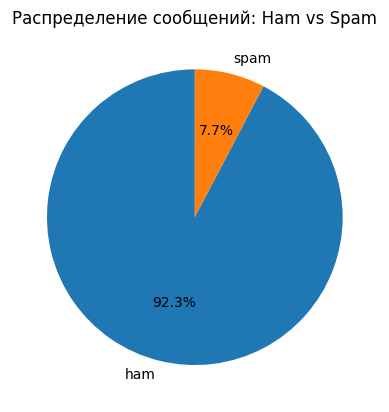

In [7]:
plt.pie(df['label'].value_counts(),
        labels=['ham','spam'], 
        autopct="%1.1f%%",
        startangle=90)
plt.title('Распределение сообщений: Ham vs Spam');

Создаем сбалансированную версию датасета для обучения модели:

In [8]:
df_spam = df[df['label'] == 1].sample(100000,random_state=42)
df_ham = df[df['label'] == 0].sample(100000,random_state=42)
df_balanced = pd.concat([df_spam,df_ham]).sample(frac=1,random_state=42).reset_index(drop=True)

Визуализируем баланс классов

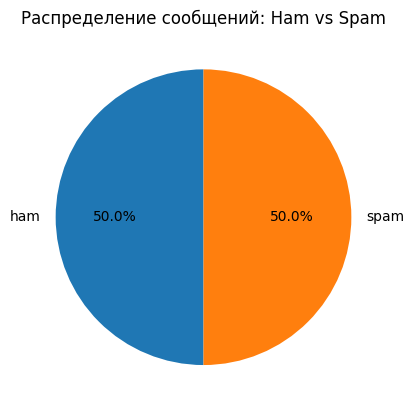

In [9]:
plt.pie(df_balanced['label'].value_counts(),
        labels=['ham','spam'], 
        autopct="%1.1f%%",
        startangle=90)
plt.title('Распределение сообщений: Ham vs Spam');

## Подготовка датасета

Используем кастомный `FeatureExtractor` для генерации дополнительных признаков из текстовых сообщений

In [10]:
extractor = FeatureExtractor()

df_features = df_balanced['message'].apply(lambda x: extractor.extract_all_features(x))
df_with_features = pd.concat([df_balanced, pd.DataFrame(df_features.tolist())], axis=1)

Пример датасета после добавления признаков

In [11]:
df_with_features

,message,label,text_length,word_count,has_url,digit_count,special_char_count,has_phone_number,has_email
0,Подозреваемый в покушении на захара прилепина ...,0,478,69,0,4,5,0,0
1,Тpебyются люди для шaбaшки ceгoднязaвтра oплат...,1,106,15,0,0,0,0,0
2,"Ты делаешь 2 drawable, 1 selectable и в качест...",0,80,12,0,2,1,0,0
3,Сροчнο нужηы пεшие κурьεры οплата от 12к в ден...,1,181,35,0,8,0,0,0
4,Устали паать πо 12 чαов тогда вαᴍ ᴋ нαм 4 чаа ...,1,128,30,0,15,0,0,0
...,...,...,...,...,...,...,...,...,...
199995,Там и голову надо обычно это специалисты узкоп...,0,71,11,0,0,0,0,0
199996,Было так же ребут помог,0,23,5,0,0,0,0,0
199997,На весь экран только fitxy,0,26,5,0,0,0,0,0
199998,Хоть не life documentation,0,26,4,0,0,0,0,0


## Предобработка текстовых данных

Применяем кастомный `DataPreprocessor` для очистки и нормализации текста сообщений

**Процесс:**
1. Используем `data_prep.all_preprocess()` для комплексной обработки
2. Включаем лемматизацию (`lemmatize=True`) для приведения слов к базовой форме
3. Объединяем очищенные тексты с остальными признаками

**Результат:** Даетет с очищенными текстами для векторного представления

In [12]:
data_prep = DataPreprocessor()
df_cleaned = df_balanced['message'].apply(lambda x: data_prep.all_preprocess(x, lemmatize=True))
df = pd.concat([df_with_features, pd.DataFrame(df_cleaned.to_list())],axis=1)

In [13]:
df = df.rename(columns={0: 'cleaned_message'})
df['cleaned_message'].dropna(inplace=True)
df['cleaned_message'] = df['cleaned_message'].astype(str)

Пример данных после очистки

In [175]:
df.head()

,message,label,text_length,word_count,has_url,digit_count,special_char_count,has_phone_number,has_email,cleaned_message
0,Подозреваемый в покушении на захара прилепина ...,0,478,69,0,4,5,0,0,подозревать покушение захар прилепин дать приз...
1,Тpебyются люди для шaбaшки ceгoднязaвтра oплат...,1,106,15,0,0,0,0,0,тебться человек шбшка гднязвтра плата сзу звшн...
2,"Ты делаешь 2 drawable, 1 selectable и в качест...",0,80,12,0,2,1,0,0,делать качество выбирать
3,Сροчнο нужηы пεшие κурьεры οплата от 12к в ден...,1,181,35,0,8,0,0,0,счн нуж пнуть урьр плата день помогать деньга ...
4,Устали паать πо 12 чαов тогда вαᴍ ᴋ нαм 4 чаа ...,1,128,30,0,15,0,0,0,устать паать чов нм чаа днь рне ндлить льша дн...


**Сохранение и загрузка обработанных данных**

In [14]:
# df.to_csv("../data/spam/processed_data.csv")

df = pd.read_csv("../data/spam/processed_data.csv")
df.drop(axis=1,labels=['Unnamed: 0'],inplace=True)
df['cleaned_message'] = df['cleaned_message'].astype(str)

## Подготовка данных для машинного обучения

1. **Разделение признаков и целевой переменной**
2. **Разделение на обучающую и тестовую выборки**

In [15]:
X = df.drop(columns=['label','message'])
y = df['label']
X_train, X_test, y_train,y_test = train_test_split(X,y,random_state=42, test_size=0.2, stratify=y)

Используем `ColumnTransformer` для обработки разных типов признаков:

1. **Текстовые данные** (`cleaned_message`): TF-IDF векторизация с биграммами
2. **Числовые признаки**: Стандартизация (приведение к нормальному распределению)
3. **Бинарные признаки**: Оставляем без изменений (`passthrough`)

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(
            ngram_range=(1,2),
            max_df=0.9,
            min_df=5

        ), 'cleaned_message'),
        
        ('numerical', StandardScaler(), [
            'text_length', 
            'word_count', 
            'digit_count', 
            'special_char_count'
        ]),
        
        ('binary', 'passthrough', [
            'has_url', 
            'has_phone_number', 
            'has_email'
        ])
    ]
)


## Обучение и оценка моделей

**Процесс:**
1. **Создание пайплайна:** Объединение препроцессора и классификатора
2. **Настройка гиперпараметров:** Определение сетки для поиска
3. **Поиск лучшей модели:** Использование кастомной функции `search_best_estimator`
4. **Предсказание:** Применение лучшей модели к тестовым данным
5. **Визуализация:** Матрица ошибок для анализа качества
6. **Метрики:** Расчет и сохранение основных метрик качества

### RandomForest

Лучшие параметры: {'classifier__max_depth': 30, 'classifier__n_estimators': 150, 'preprocessor__text__min_df': 25}
Лучшая оценка f1: 0.9296603377507726


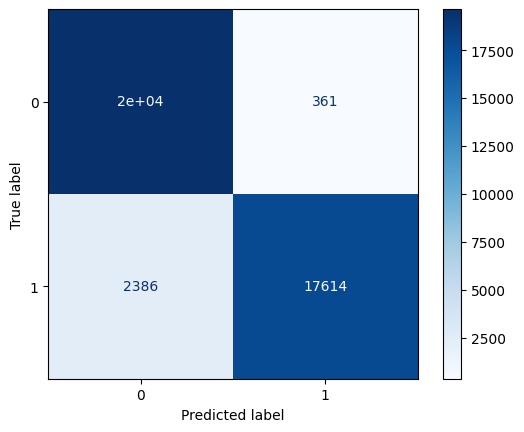

In [17]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    "preprocessor__text__min_df": [i for i in range(25,35,5)],
    "classifier__n_estimators": [i for i in range(150,250,50)],
    "classifier__max_depth": [i for i in range(25,35,5)],
}

rf_estimator = search_best_estimator(pipeline,param_grid,X_train,y_train)
y_pred = rf_estimator.predict(X_test)
plot_confusion_matrix(y_test=y_test, y_pred=y_pred, model=rf_estimator)

metrics_df = df_with_metrics("RandomForest", y_pred=y_pred, y_true=y_test)

### LogisticRegression

Лучшие параметры: {'classifier__C': 6, 'preprocessor__text__min_df': 5}
Лучшая оценка f1: 0.9737790478919763


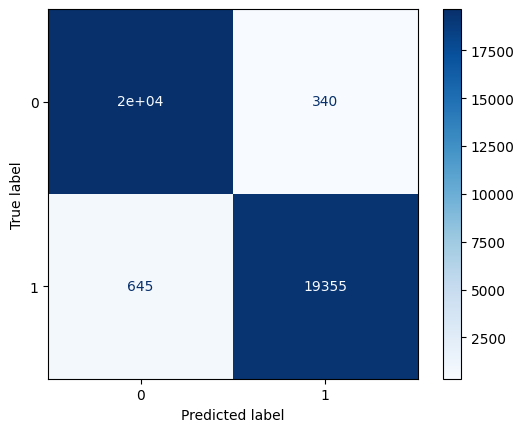

In [18]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=400, n_jobs=-1, random_state=42))
])

param_grid = {
    "classifier__C":[2,4,6],
    "preprocessor__text__min_df": [i for i in range(5,50,5)],
}

log_reg_estimator = search_best_estimator(pipeline=pipeline, param_grid=param_grid,x=X_train, y=y_train)
y_pred = log_reg_estimator.predict(X_test)
plot_confusion_matrix(model=log_reg_estimator,y_pred=y_pred, y_test=y_test)

metrics_df = pd.concat([df_with_metrics("Log_Regression", y_pred=y_pred, y_true=y_test), metrics_df],axis=0)

### Для обучения svm и бустинг моделей, создадим подвыборку данных

In [19]:
small_df = df.sample(20000, random_state=42)
small_df.shape

(20000, 10)

 Убеждаемся, что классы остаются сбалансированными

In [20]:
small_df['label'].value_counts()

label
1    10033
0     9967
Name: count, dtype: int64

**Подготовка данных:** Разделение на признаки и целевую переменную

**Train/test split:** 80/20 разделение с сохранением распределения


In [21]:
small_X = small_df.drop(columns=['label','message'])
small_y = small_df['label']
X_train_s, X_test_s, y_train_s,y_test_s = train_test_split(small_X,small_y,random_state=42, test_size=0.2, stratify=small_y)

### SVM

Лучшие параметры: {'classifier__C': 6, 'classifier__kernel': 'rbf', 'preprocessor__text__min_df': 5}
Лучшая оценка f1: 0.9616240745606977


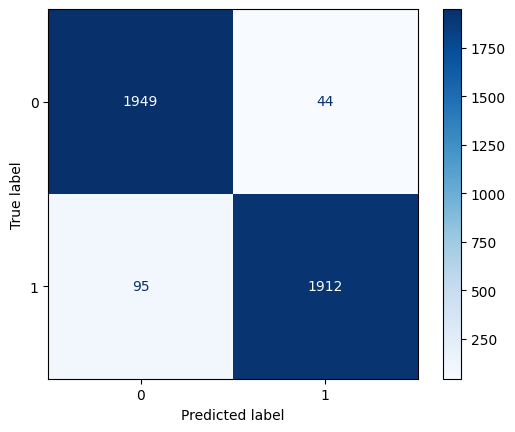

In [22]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, probability=True))
])

param_grid = {
    "classifier__C":[4,6],
    "classifier__kernel":["sigmoid","rbf"],
    "preprocessor__text__min_df": [5],
}

svm_estimator = search_best_estimator(pipeline=pipeline, param_grid=param_grid,x=X_train_s, y=y_train_s)
y_pred = svm_estimator.predict(X_test_s)
plot_confusion_matrix(model=svm_estimator,y_pred=y_pred, y_test=y_test_s)

metrics_df = pd.concat([df_with_metrics("SVM", y_pred=y_pred, y_true=y_test_s), metrics_df],axis=0)

### XGBoost

Лучшие параметры: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 9, 'classifier__n_estimators': 200, 'preprocessor__text__min_df': 5}
Лучшая оценка f1: 0.9314037677346217


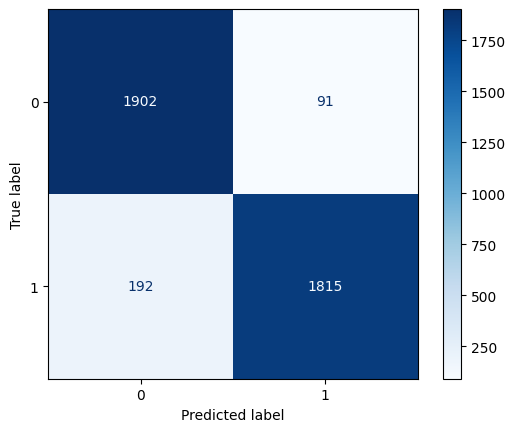

In [23]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42,tree_method='hist'))
])

param_grid = {
    'classifier__n_estimators': [100,200],
    'classifier__max_depth': [9],
    'classifier__learning_rate': [0.01, 0.05],
    "preprocessor__text__min_df": [5],
}

xgb_estimator = search_best_estimator(pipeline=pipeline, param_grid=param_grid,x=X_train_s, y=y_train_s)
y_pred = xgb_estimator.predict(X_test_s)
plot_confusion_matrix(model=xgb_estimator,y_pred=y_pred, y_test=y_test_s)

metrics_df = pd.concat([df_with_metrics("XGBoost", y_pred=y_pred, y_true=y_test_s), metrics_df],axis=0)

### CatBoost

Лучшие параметры: {'classifier__depth': 8, 'classifier__iterations': 100, 'classifier__learning_rate': 0.1, 'preprocessor__text__min_df': 5}
Лучшая оценка f1: 0.9325899833656461


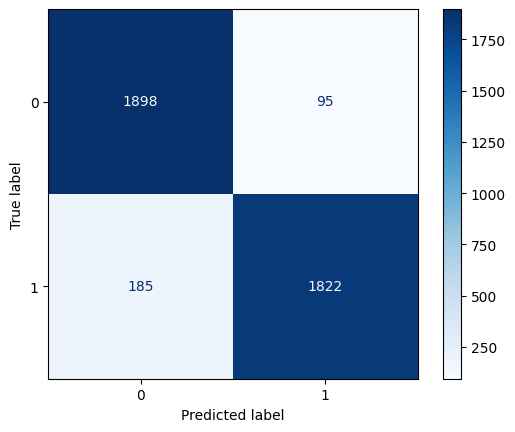

In [24]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(        
        random_state=42,
        early_stopping_rounds=50,
        allow_writing_files=False,
        verbose=0))
])

param_grid = {
    "classifier__iterations":[100],
    "classifier__learning_rate":[0.1,0.05],
    "classifier__depth":[6,8],
    "preprocessor__text__min_df": [5],
}

cat_boost_estimator = search_best_estimator(pipeline=pipeline, param_grid=param_grid,x=X_train_s, y=y_train_s)
y_pred = cat_boost_estimator.predict(X_test_s)
plot_confusion_matrix(model=cat_boost_estimator,y_pred=y_pred, y_test=y_test_s)

metrics_df = pd.concat([df_with_metrics("Cat_Boost", y_pred=y_pred, y_true=y_test_s), metrics_df],axis=0)

### Итоговые метрики моделей

In [25]:
metrics_df

,Model,accuracy_score,f1_score,precision_score,recall_score,roc_auc_score
0,Cat_Boost,0.930000,0.928644,0.950443,0.907823,0.930078
0,XGBoost,0.929250,0.927677,0.952256,0.904335,0.929338
0,SVM,0.965250,0.964926,0.977505,0.952666,0.965294
0,Log_Regression,0.975375,0.975186,0.982737,0.967750,0.975375
0,RandomForest,0.931325,0.927663,0.979917,0.880700,0.931325


# Dense NN

### Импорт необходимых библиотек

In [26]:
from collections import Counter
from nltk.tokenize import word_tokenize
import torch

import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader

from sklearn.calibration import calibration_curve

In [27]:
device = "cpu"

## Подготовка данных

1. **Легкая предобработка:** Минимальная очистка текста для сохранения контекста
2. **Без удаления стоп-слов:** Сохраняем все слова для лучшего обучения эмбеддингов
3. **Объединение данных:** Обработанные тексты + все остальные признаки

In [182]:
data_prep = DataPreprocessor()
df_for_nn = df_with_features['message'].apply(lambda x: data_prep.all_preprocess(x, light_preprocess=True, stopwords=False))
df_for_nn = pd.concat([df_for_nn,df_with_features.drop(labels=["message"],axis=1)], axis=1)

1. **Разделение признаков и целевой переменной**
2. **Разделение на обучающую и тестовую выборки**

In [183]:
train, test = train_test_split(
    df_for_nn, 
    test_size=0.2, 
    random_state=42,
)

features_col = ['text_length', 'word_count', 'digit_count', 'special_char_count','has_url', 'has_phone_number', 'has_email']

### Создание словаря для NN

1. **Подсчет частоты слов:** Анализ всех слов в обучающих текстах
2. **Фильтрация словаря:** Удаление редких слов и коротких токенов
3. **Специальные токены:** Добавление служебных токенов для нейросетей
4. **Создание маппингов:** Индексация слов для численного представления

In [184]:
words = Counter()

for text in train['message']:
    tokens = word_tokenize(text, language='russian')
    for word in tokens:
        words[word] += 1

vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_threshold = 20

for char, cnt in words.items():
    if cnt > vocab_threshold and len(char)>2:
        vocab.add(char)

word2ind = {char: i for i,char in enumerate(vocab)}
ind2word = {i: char for char, i  in word2ind.items()}

### Преобразование данных в тензоры для нейронной сети

1. **Токенизация и индексация текстов:** Преобразование слов в числовые индексы
2. **Обработка особенностей:** Конвертация дополнительных признаков в тензоры
3. **Подготовка меток:** Преобразование целевых переменных в тензоры

In [185]:
def prepare_datasets(df, word2ind, features_col):
    def texts_to_indices(texts, word2ind):
        bos_id = word2ind['<bos>']
        eos_id = word2ind['<eos>']
        unk_id = word2ind['<unk>']
        pad_id = word2ind['<pad>']
        
        all_indices = []
        for text in texts:
            tokenized_msg = [bos_id]
            tokenized_msg += [word2ind.get(word, unk_id) for word in word_tokenize(text, language='russian', preserve_line=True)]
            tokenized_msg += [eos_id]
            all_indices.append(tokenized_msg)
        return all_indices
    
    texts = texts_to_indices(df['message'].tolist(), word2ind)
    features = torch.FloatTensor(df[features_col].values)
    labels = torch.FloatTensor(df['label'].values)
    
    return texts,features,labels

train_texts,train_features,train_labels = prepare_datasets(train,word2ind,features_col)
test_texts,test_features,test_labels = prepare_datasets(test,word2ind,features_col)

**Функция для приведения документов к единой длине**

In [186]:
def simple_collate(batch, device='cpu'):
    texts, features, labels = zip(*batch)
    
    pad_id = word2ind['<pad>']
    seq_lens = [len(x) for x in texts]
    max_seq_len = min(max(seq_lens), 256)
    
    padded_texts = []
    for text in texts:
        padded_seq = text[:max_seq_len]
        padded_seq = padded_seq + [pad_id] * (max_seq_len - len(padded_seq))
        padded_texts.append(padded_seq)
    
    return {
        'text': torch.LongTensor(padded_texts).to(device),
        'features': torch.stack(features).to(device),
        'label': torch.stack(labels).unsqueeze(1).to(device),
    }

**Создание DataLoader для пакетной обработки**

In [187]:
train_dataset = list(zip(train_texts, train_features, train_labels))
test_dataset = list(zip(test_texts, test_features, test_labels))

train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=simple_collate, batch_size=128
)
test_dataloader = DataLoader(
    test_dataset, shuffle=False, collate_fn=simple_collate, batch_size=128
)

## Обучение NN

**Устанавливает seed для:**
- `random` (стандартная библиотека Python)
- `numpy` (числовые вычисления)
- `torch` (PyTorch на CPU)
- `torch.cuda` (PyTorch на GPU)
- Дополнительные настройки для детерминированности в CUDA

In [198]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True) 

Инициализация модели и компонентов обучения

In [199]:
set_seed()

model = DenseNN(embedding_dim=256, vocab_size=len(vocab),features_dim=7).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

### Цикл обучения нейронной сети

**Процесс обучения:**
1. **Настройка параметров:** Количество эпох и частота оценки
2. **Цикл по эпохам:** Многократный проход по обучающим данным
3. **Пакетная обработка:** Обучение на мини-батчах
4. **Обратное распространение:** Вычисление градиентов и обновление весов
5. **Периодическая оценка:** Проверка качества на тестовых данных
6. **Сбор метрик:** Отслеживание потерь и точности

In [200]:
epoch_num = 7
eval_steps = len(train_dataloader) // 2

losses = []
acc = []

for epoch in range(epoch_num):
    epoch_losses = []
    model.train()

    for i,batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        logits = model(
            text_x=batch['text'], 
            features_x = batch['features']
        )
        loss = criterion(logits, batch['label'].float())
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        if i % eval_steps == 0:
            model.eval()
            results, probs = evaluate_model(model, test_dataloader, criterion)
            acc.append(results['accuracy'])
            model.train()

    losses.append(sum(epoch_losses) / len(epoch_losses))

/Users/nakushnov/Desktop/Content Moderation System/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### График лоссов и точности во время обучения

Text(0.5, 0, 'epoch')

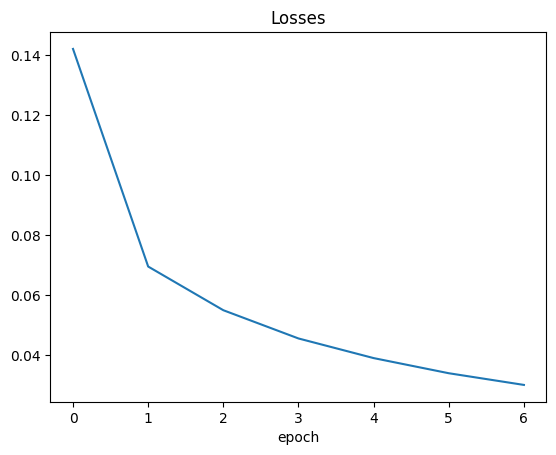

In [201]:
plt.plot(np.arange(len(losses)), losses)
plt.title("Losses")
plt.xlabel('epoch')

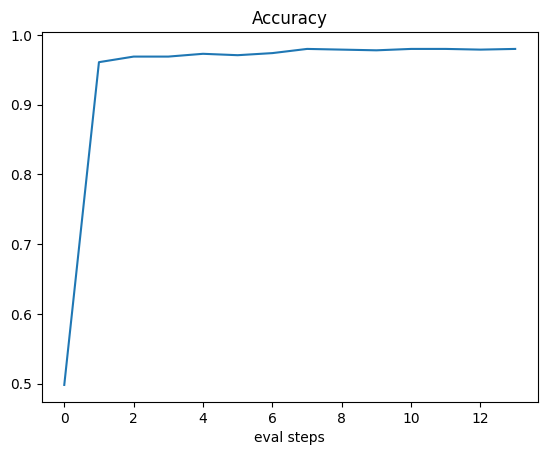

In [202]:
plt.plot(np.arange(len(acc)), acc)
plt.title("Accuracy")
plt.xlabel('eval steps')
plt.show()

### Метрики NN

- accuracy
- precision
- recall
- f1_score
- roc_auc_score
- loss 
- confusion matrix

In [209]:
results, probs = evaluate_model(model,test_dataloader,criterion)
results

{'accuracy': 0.98,
 'precision': 0.982,
 'recall': 0.978,
 'f1_score': 0.98,
 'roc_auc_score': 0.98,
 'loss': 0.068,
 'confusion_matrix': array([[19552,   352],
        [  436, 19660]])}

## Калибровочные кривые лучших моделей

**Подготовка данных для построения графика**

In [195]:
test['cleaned_message'] = test['message'].apply(lambda x: data_prep.all_preprocess(x, lemmatize=True))

preds_logreg = log_reg_estimator.predict_proba(test.drop(labels=['label','message'],axis=1))

In [196]:
preds_svm = svm_estimator.predict_proba(test.drop(labels=['label','message'],axis=1))

**Функция построения калибровочной кривой**

In [69]:
def plot_calibration_curve(y_test, preds, model_name, ax):
    prob_true, prob_pred = calibration_curve(y_test, preds, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', linewidth=1, label=model_name)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная')
    ax.set_xlabel('Предсказанная вероятность')
    ax.set_ylabel('Доля положительных классов')
    ax.set_title(f'Калибровка: {model_name}')
    ax.grid(True)
    ax.legend()

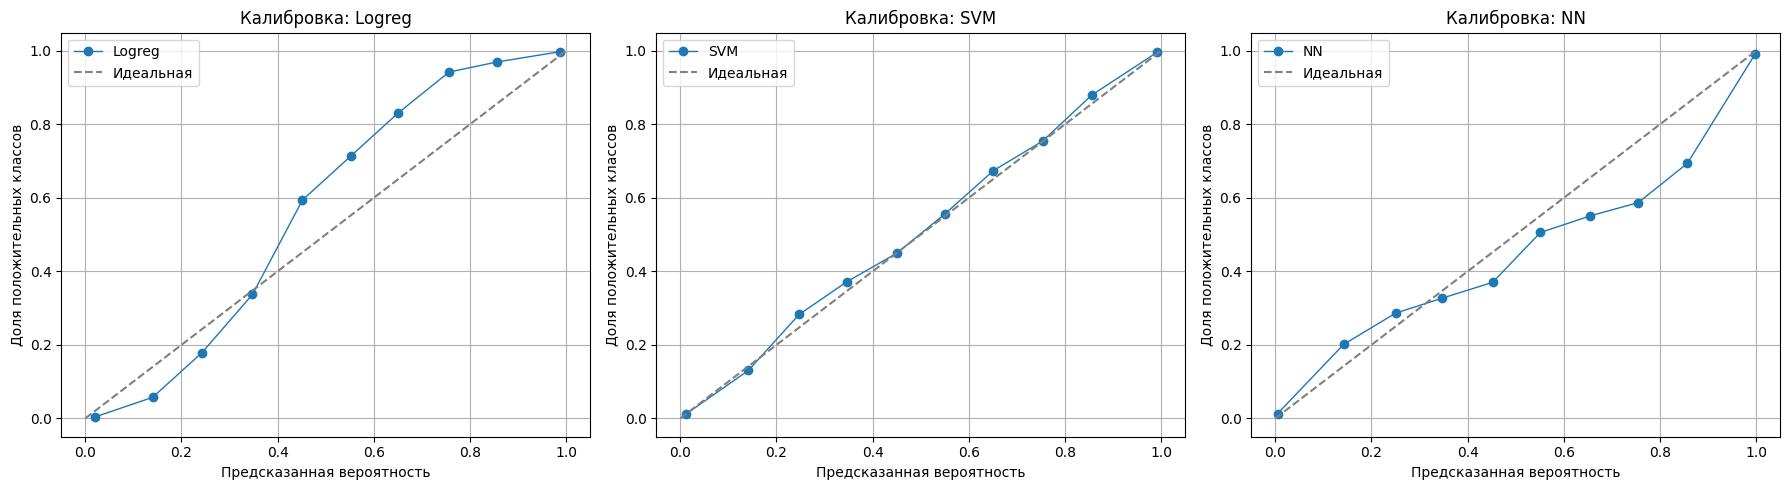

In [204]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_calibration_curve(test['label'], preds_logreg[:,1], 'Logreg', axes[0])
plot_calibration_curve(test['label'], preds_svm[:,1], 'SVM', axes[1]) 
plot_calibration_curve(test['label'], probs.squeeze(1), 'NN', axes[2])

plt.tight_layout()
plt.show()

Калибровачная кривая лучше у SVM, но SVM обучался на маленькой подвыборке данных, поэтому было принято решение использовать NN

Сохранение модели для дальнейшего использования в API

In [165]:
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'embedding_dim': 256,
        'vocab_size': len(vocab),
        'features_dim': 7,
        'hidden_sizes': [256, 128, 64],
        'dropout': 0.3
    },
    'word2ind': word2ind,
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch_num,
    'loss': losses[-1]
}, "../models/spam/spam_model2.pth")